In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.layers import LSTM, Dense, Dropout, SimpleRNN, GRU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import keras_tuner as kt
from datetime import timedelta

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import random
import tensorflow as tf

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)
    
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

seed_everything(42)


Understanding dataset nature

In [3]:
data = pd.read_csv('AEP_hourly.csv')
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [4]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.0 MB


Preparing data for time series forecasting

In [6]:
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB


In [8]:
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [9]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [10]:
data.set_index('Datetime', inplace = True)

In [11]:
data.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


EDA

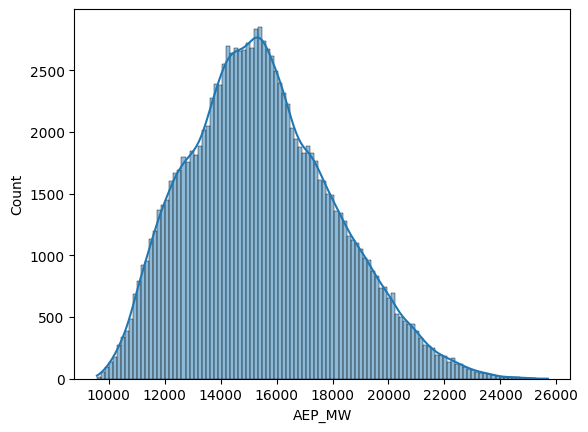

In [12]:
plt.figure()
sns.histplot(data['AEP_MW'], kde = True)
plt.show()

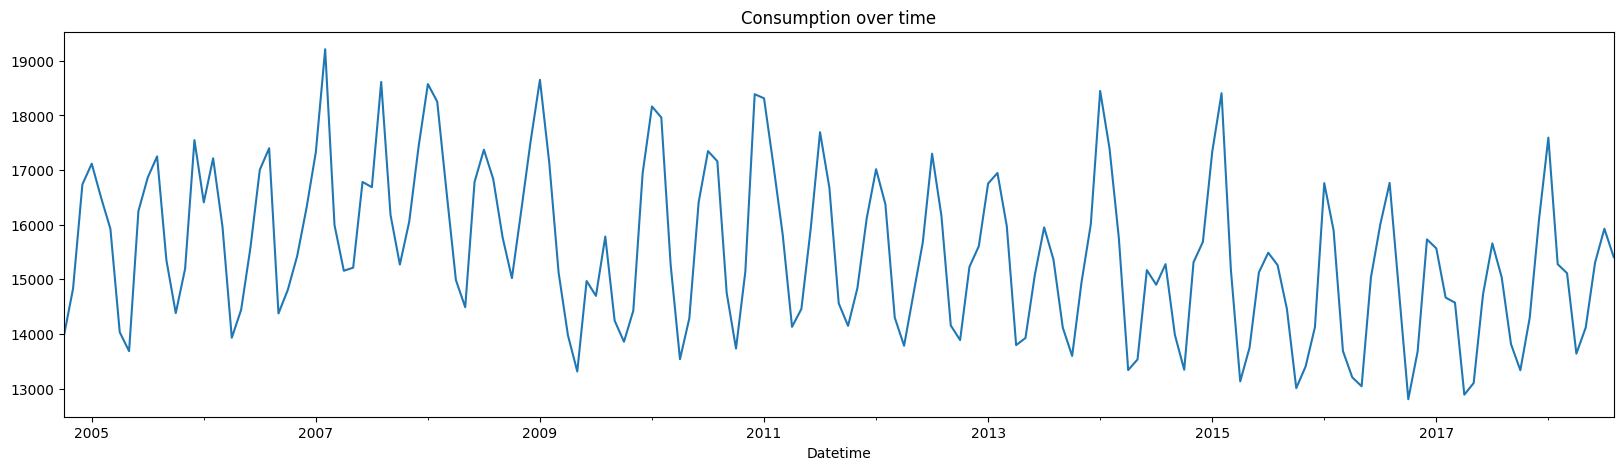

In [13]:
data_2 = data[['AEP_MW']].resample('ME').mean().copy()
data_2['AEP_MW'].plot(title=f"Consumption over time", figsize=(20, 5))
plt.show()

Train test Split

In [14]:
data_time = data.resample('D').mean().copy()

In [16]:
data_time.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5055 entries, 2004-10-01 to 2018-08-03
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AEP_MW  5055 non-null   float64
dtypes: float64(1)
memory usage: 79.0 KB


In [15]:
size = int(len(data_time)*0.8)
train_dataset = data_time.iloc[:size].copy()
test_dataset = data_time.iloc[size:].copy()

In [16]:
print(f"p_value: {sts.adfuller(train_dataset['AEP_MW'])[1]}")

p_value: 1.1991833341238702e-09


In [17]:
test_dataset[['AEP_MW']]

,AEP_MW
Datetime,
2015-10-28,13596.416667
2015-10-29,13321.541667
2015-10-30,13729.291667
2015-10-31,12783.916667
2015-11-01,11654.040000
...,...
2018-07-30,15368.083333
2018-07-31,15180.291667
2018-08-01,15151.166667


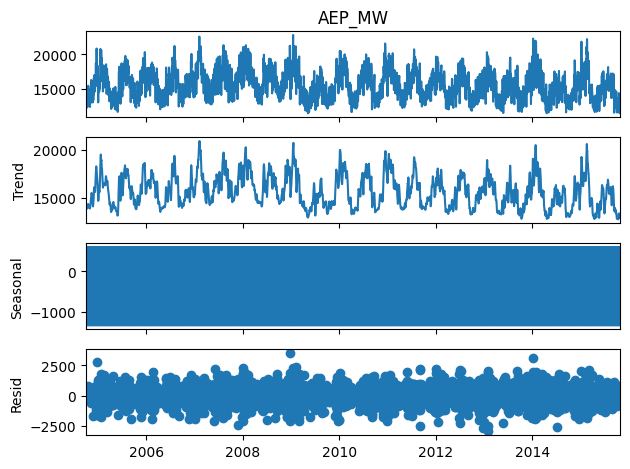

In [18]:
s_dec_additive = seasonal_decompose(train_dataset['AEP_MW'], model='additive')
s_dec_additive.plot()
plt.show()

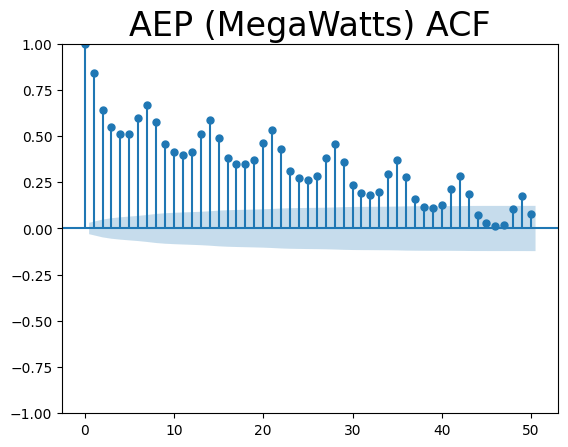

In [19]:
sgt.plot_acf(train_dataset['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

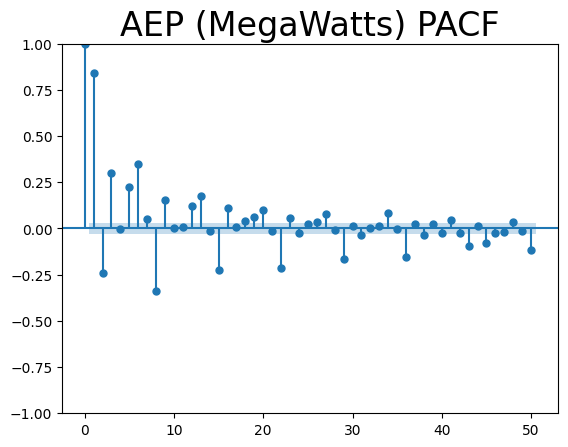

In [20]:
sgt.plot_pacf(train_dataset['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [21]:
stationary_data = train_dataset[['AEP_MW']].diff(7).dropna().copy()

In [22]:
stationary_data

,AEP_MW
Datetime,
2004-10-08,65.811594
2004-10-09,-65.333333
2004-10-10,33.291667
2004-10-11,-9.291667
2004-10-12,175.208333
...,...
2015-10-23,-63.583333
2015-10-24,-802.416667
2015-10-25,-1429.250000


In [23]:
print(f"p_value: {sts.adfuller(stationary_data['AEP_MW'])[1]}")

p_value: 1.4812563470244643e-21


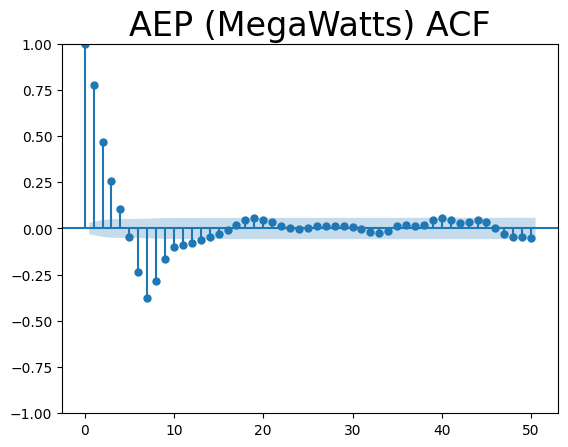

In [24]:
sgt.plot_acf(stationary_data['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

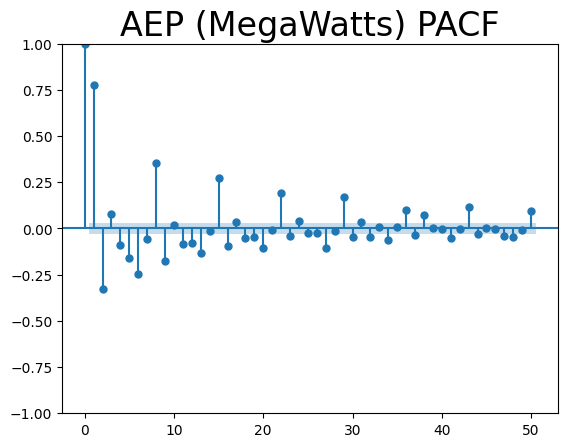

In [25]:
sgt.plot_pacf(stationary_data['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [26]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(2, 0, 0),           
                       seasonal_order=(1, 0, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              AEP_MW   No. Observations:                 4044
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 7)   Log Likelihood              -32841.978
Date:                             Thu, 11 Jun 2026   AIC                          65693.957
Time:                                     20:06:34   BIC                          65725.470
Sample:                                 10-01-2004   HQIC                         65705.122
                                      - 10-27-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1143      0.028     40.394      0.000       1.060       1.168
ar.L2         -0.2261      

In [27]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [28]:
y_pred_train = results_sarima.fittedvalues

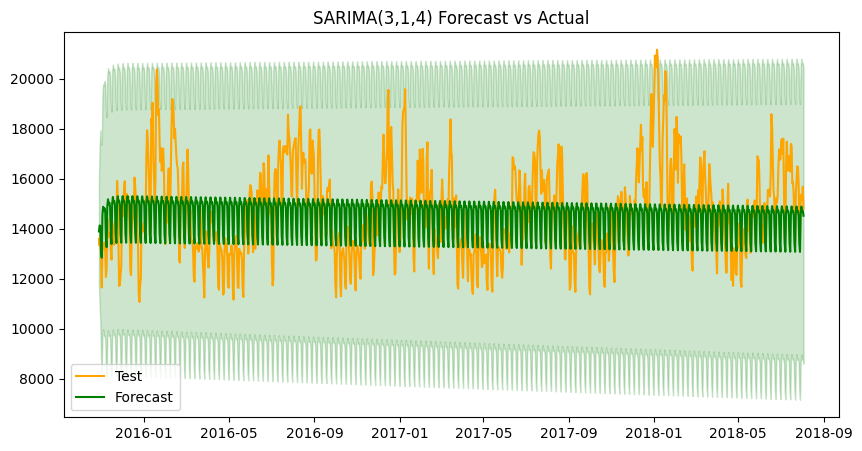

In [29]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [30]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))
train_r2 = r2_score(train_dataset['AEP_MW'], y_pred_train)
test_r2 = r2_score(test_dataset['AEP_MW'], y_pred)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 547.59
Test MAE : 1396.67
Train RMSE: 803.06
Test RMSE: 1745.62
Train R2: 0.83
Test R2: 0.08


In [31]:
mape_train = (abs(train_dataset['AEP_MW'] - y_pred_train) / abs(train_dataset['AEP_MW'])).mean() * 100
mape_test  = (abs(test_dataset['AEP_MW']  - y_pred)  / abs(test_dataset['AEP_MW'])).mean()  * 100
print(f"Train MAPE: {mape_train:.2f}%")
print(f"Test MAPE:  {mape_test:.2f}%")

Train MAPE: 3.46%
Test MAPE:  9.31%


In [32]:
model_arima = ARIMA(train_dataset['AEP_MW'], order=(2,0,0))
results_arima = model_arima.fit()
results_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 AEP_MW   No. Observations:                 4044
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -33760.492
Date:                Thu, 11 Jun 2026   AIC                          67528.984
Time:                        20:06:34   BIC                          67554.204
Sample:                    10-01-2004   HQIC                         67537.919
                         - 10-27-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.569e+04     88.855    176.635      0.000    1.55e+04    1.59e+04
ar.L1          1.0472      0.016     64.037      0.000       1.015       1.079
ar.L2         -0.2424      0.017    -14.619      0.000      -0.275      -0.210
sigma2      1.044e+06    2.2e+04     47.423      0.000       1e+06    1.09e+06
===================================================================================
Ljung-Box (L1) (Q):                  21.77   Jarque-Bera (JB):               258.65
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.56
Prob(H) (two-sided):                  0.50   Kurtosis:                         3.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
n_steps = len(test_dataset)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [34]:
y_pred_train = results_arima.fittedvalues

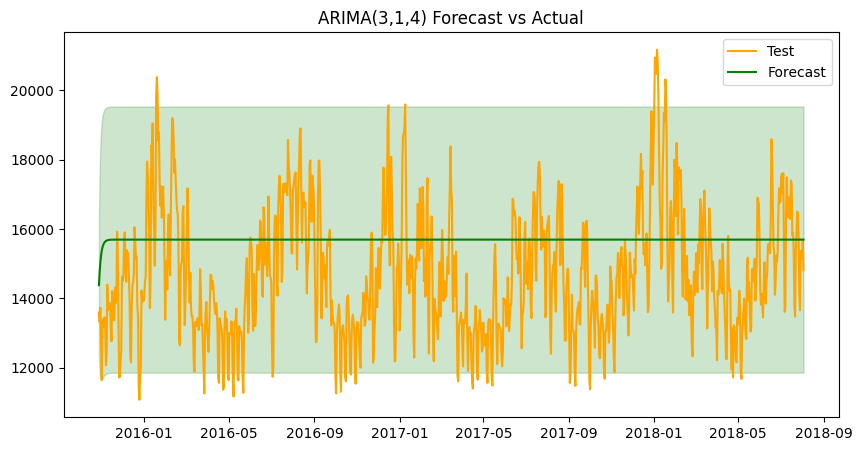

In [35]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [36]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))
train_r2 = r2_score(train_dataset['AEP_MW'], y_pred_train)
test_r2 = r2_score(test_dataset['AEP_MW'], y_pred)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 800.04
Test MAE : 1739.28
Train RMSE: 1021.85
Test RMSE: 2063.47
Train R2: 0.73
Test R2: -0.28


Comparing ARIMA and SARIMA Residuals

In [37]:
arima_resid = results_arima.resid
sarima_resid = results_sarima.resid

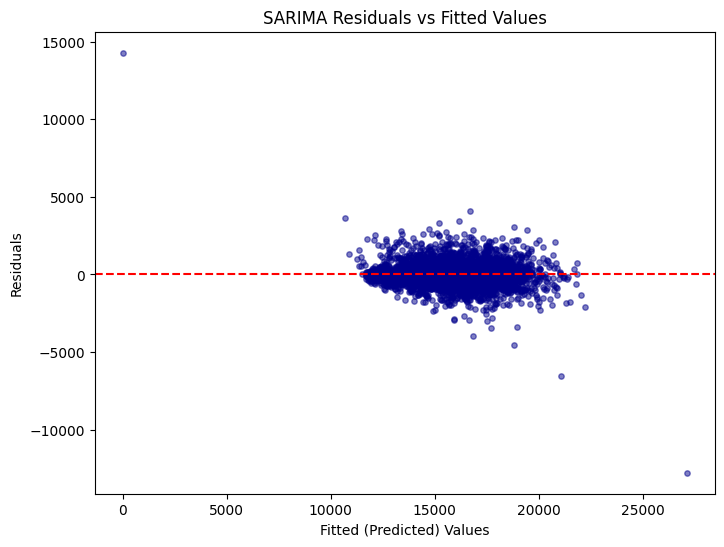

In [38]:
fitted_values = results_sarima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_sarima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('SARIMA Residuals vs Fitted Values')
plt.show()

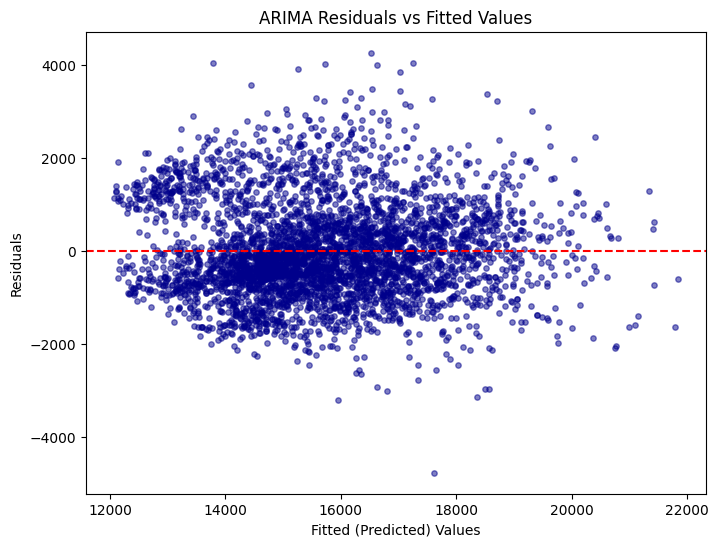

In [39]:
fitted_values = results_arima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_arima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('ARIMA Residuals vs Fitted Values')
plt.show()

In [40]:
train_proph = train_dataset.copy()
train_proph.reset_index(inplace = True)
train_proph.head()

,Datetime,AEP_MW
0,2004-10-01,14284.521739
1,2004-10-02,12999.875000
2,2004-10-03,12227.083333
3,2004-10-04,14309.041667
4,2004-10-05,14439.708333


In [41]:
train_proph = train_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
train_proph.head()

,ds,y
0,2004-10-01,14284.521739
1,2004-10-02,12999.875000
2,2004-10-03,12227.083333
3,2004-10-04,14309.041667
4,2004-10-05,14439.708333


In [42]:
model = Prophet()
model.fit(train_proph)

20:06:35 - cmdstanpy - INFO - Chain [1] start processing
20:06:36 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
test_proph = test_dataset.copy()
test_proph.reset_index(inplace = True)
test_proph.head()

,Datetime,AEP_MW
0,2015-10-28,13596.416667
1,2015-10-29,13321.541667
2,2015-10-30,13729.291667
3,2015-10-31,12783.916667
4,2015-11-01,11654.040000


In [44]:
test_proph = test_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
test_proph.head()

,ds,y
0,2015-10-28,13596.416667
1,2015-10-29,13321.541667
2,2015-10-30,13729.291667
3,2015-10-31,12783.916667
4,2015-11-01,11654.040000


In [45]:
forecast = model.predict(test_proph)

In [46]:
forecast_train = model.predict(train_proph)

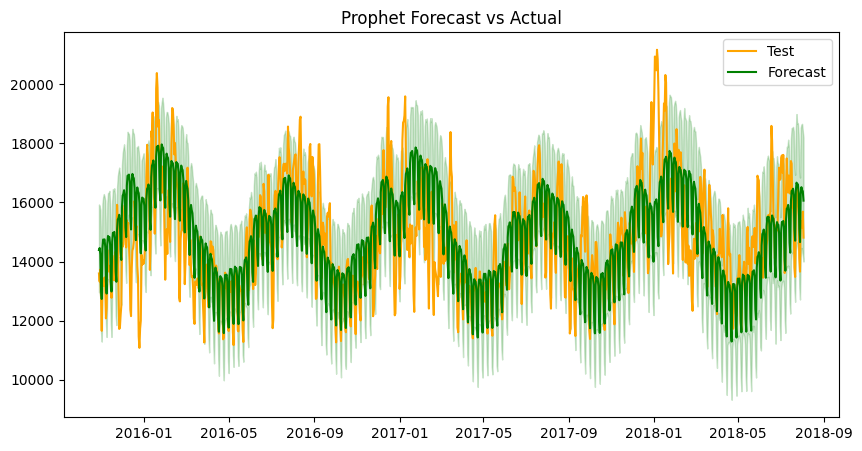

In [47]:
plt.figure(figsize=(10,5))
#plt.plot(train_proph['ds'], train_proph['y'], label='Train')
plt.plot(test_proph['ds'], test_proph['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'],
                 forecast['yhat_upper'],
                 forecast['yhat_lower'],
                 color='green', alpha=0.2)
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.show()

In [48]:
mae = mean_absolute_error(test_proph['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_proph['y'], forecast['yhat']))
mae_train = mean_absolute_error(train_proph['y'], forecast_train['yhat'])
rmse_train = np.sqrt(mean_squared_error(train_proph['y'], forecast_train['yhat']))
train_r2 = r2_score(train_proph['y'], forecast_train['yhat'])
test_r2 = r2_score(test_proph['y'], forecast['yhat'])

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 886.63
Test MAE : 1105.87
Train RMSE: 1155.84
Test RMSE: 1434.90
Train R2: 0.65
Test R2: 0.38


In [49]:
data_3 = data_time.copy()
data_3.head()

,AEP_MW
Datetime,
2004-10-01,14284.521739
2004-10-02,12999.875000
2004-10-03,12227.083333
2004-10-04,14309.041667
2004-10-05,14439.708333


In [50]:
#scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_3)

In [51]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False, random_state = 42
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [52]:
model = Sequential()
model.add(SimpleRNN(units=128, activation = 'relu',return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.35))
model.add(SimpleRNN(units=128, activation = 'relu'))
model.add(Dropout(0.35))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3365 - val_loss: 0.2187
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2205 - val_loss: 0.2010
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1966 - val_loss: 0.1881
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1898 - val_loss: 0.1779
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1780 - val_loss: 0.1743
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1859 - val_loss: 0.1899
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1792 - val_loss: 0.1901
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1704 - val_loss: 0.1940
Epoch 9/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1710 - val_loss: 0.1797
Epoch 10/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1657 - val_loss: 0.1790
Epoch 11/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1642 - val_loss: 0.2074
Epoch 12/100
114/114 ━━━━━━━━━━━━━━━━━━━━

In [54]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [55]:
mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

Train MAE : 585.60
Test MAE : 651.93
Train RMSE: 766.94
Test RMSE: 832.32
Train R2 Score: 0.8464535521424508
Test R2 Score: 0.791427623300464


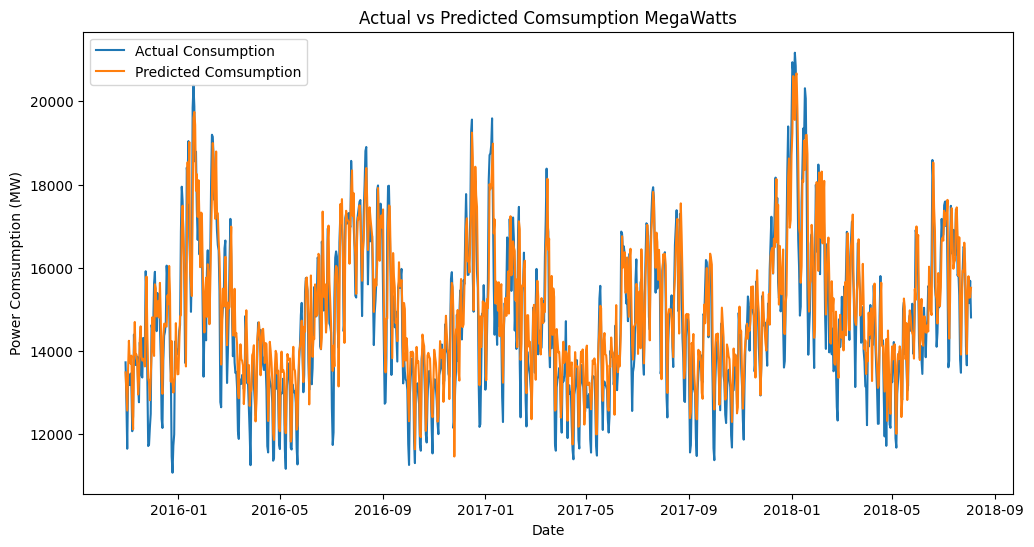

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Comsumption (MW)')
plt.legend()
plt.show()

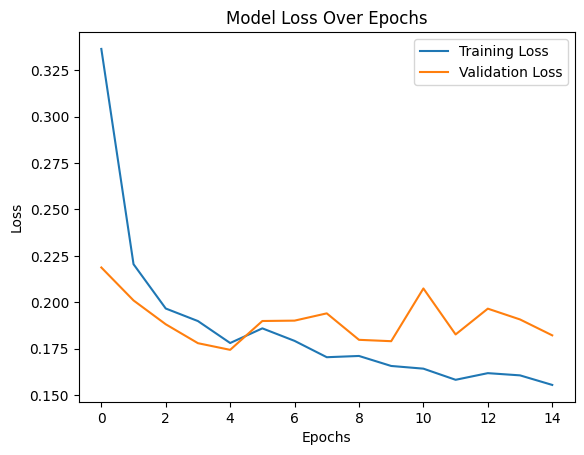

In [57]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [63]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.35))
model.add(LSTM(units=128))
model.add(Dropout(0.35))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [64]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5176 - val_loss: 0.4344
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4092 - val_loss: 0.3032
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2753 - val_loss: 0.2623
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2427 - val_loss: 0.2372
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2268 - val_loss: 0.2317
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2168 - val_loss: 0.2146
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2044 - val_loss: 0.2021
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1928 - val_loss: 0.1991
Epoch 9/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1902 - val_loss: 0.1951
Epoch 10/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1840 - val_loss: 0.1879
Epoch 11/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1843 - val_loss: 0.1893
Epoch 12/100
114/114 ━━━━━━━━━

In [65]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Train MAE : 564.78
Test MAE : 618.12
Train RMSE: 754.75
Test RMSE: 809.87
Train R2 Score: 0.8512965270703092
Test R2 Score: 0.8025276836073632


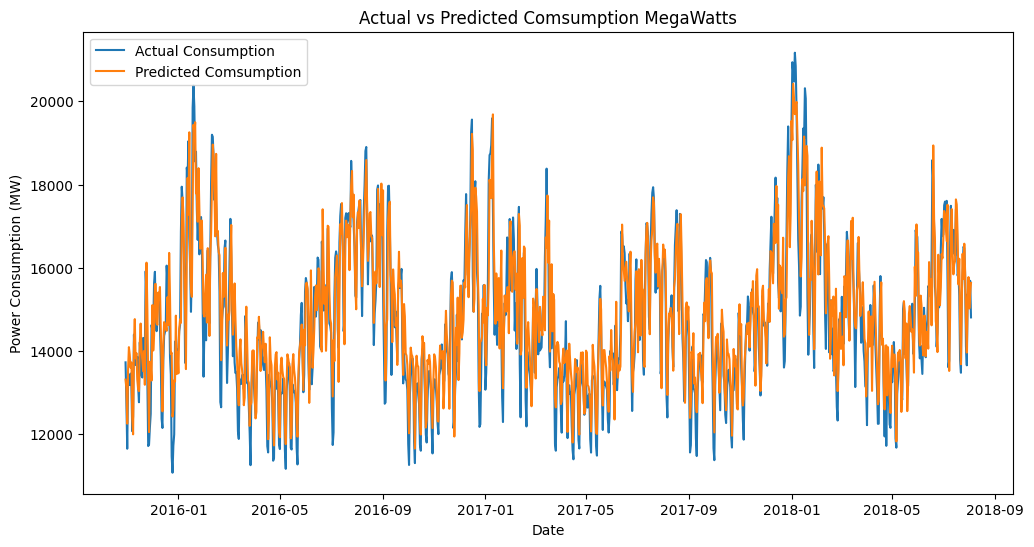

In [64]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

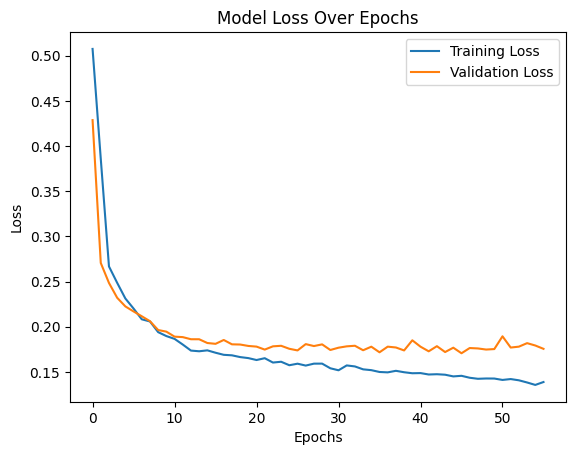

In [65]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [66]:
model = Sequential()
model.add(GRU(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.35))
model.add(GRU(units=128))
model.add(Dropout(0.35))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3738 - val_loss: 0.2488
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.2419 - val_loss: 0.2329
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2289 - val_loss: 0.2195
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.2171 - val_loss: 0.2039
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2090 - val_loss: 0.2039
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2018 - val_loss: 0.2102
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1927 - val_loss: 0.2095
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1873 - val_loss: 0.2019
Epoch 9/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1835 - val_loss: 0.2062
Epoch 10/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1795 - val_loss: 0.1988
Epoch 11/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1762 - val_loss: 0.1969
Epoch 12/100
114/114 ━━━━━━━━━

In [68]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train MAE : 561.38
Test MAE : 624.25
Train RMSE: 742.80
Test RMSE: 815.32
Train R2 Score: 0.8559696743341378
Test R2 Score: 0.7998644769971804


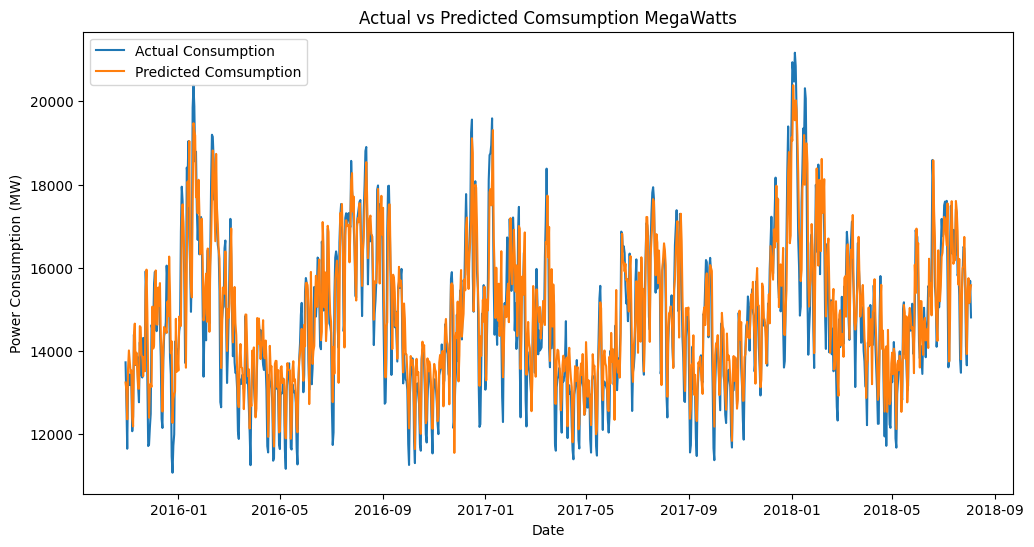

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

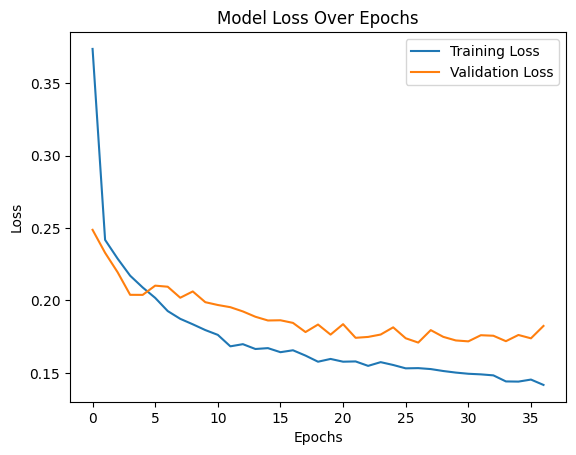

In [70]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [71]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth = 3)

In [72]:
ML_train = train_proph.copy()
ML_test = test_proph.copy()

In [73]:
ML_train['year'] = ML_train['ds'].dt.year
ML_train['month'] = ML_train['ds'].dt.month
ML_train['day'] = ML_train['ds'].dt.day
ML_train['dayofweek'] = ML_train['ds'].dt.dayofweek   
ML_train['dayofyear'] = ML_train['ds'].dt.dayofyear   
ML_train['is_weekend'] = ML_train['dayofweek'].isin([5, 6]).astype(int)
ML_train['lag_1'] = ML_train['y'].shift(1)
ML_train['lag_2'] = ML_train['y'].shift(2)
ML_train['lag_7'] = ML_train['y'].shift(7)
ML_train = ML_train.dropna().reset_index(drop=True)
ML_train.drop(columns = ['ds'], inplace = True)

In [74]:
ML_test['year'] = ML_test['ds'].dt.year
ML_test['month'] = ML_test['ds'].dt.month
ML_test['day'] = ML_test['ds'].dt.day
ML_test['dayofweek'] = ML_test['ds'].dt.dayofweek   
ML_test['dayofyear'] = ML_test['ds'].dt.dayofyear   
ML_test['is_weekend'] = ML_test['dayofweek'].isin([5, 6]).astype(int)
ML_test['lag_1'] = ML_test['y'].shift(1)
ML_test['lag_2'] = ML_test['y'].shift(2)
ML_test['lag_7'] = ML_test['y'].shift(7)
ML_test = ML_test.dropna().reset_index(drop=True)
ML_test.drop(columns = ['ds'], inplace = True)

In [75]:
ML_train.head()

,y,year,month,day,dayofweek,dayofyear,is_weekend,lag_1,lag_2,lag_7
0,14350.333333,2004,10,8,4,282,0,14449.416667,14424.791667,14284.521739
1,12934.541667,2004,10,9,5,283,1,14350.333333,14449.416667,12999.875000
2,12260.375000,2004,10,10,6,284,1,12934.541667,14350.333333,12227.083333
3,14299.750000,2004,10,11,0,285,0,12260.375000,12934.541667,14309.041667
4,14614.916667,2004,10,12,1,286,0,14299.750000,12260.375000,14439.708333


In [76]:
X_train, y_train = ML_train.drop(columns = 'y'), ML_train[['y']]
X_test, y_test = ML_test.drop(columns = 'y'), ML_test[['y']]

In [77]:
rf_model.fit(X_train, y_train)

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [78]:
train_preds_rf = rf_model.predict(X_train)
test_preds_rf = rf_model.predict(X_test)

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_rf)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_rf)}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, train_preds_rf))}")
print(f"Testing RMSE score: {np.sqrt(mean_squared_error(y_test, test_preds_rf))}")
print(f"Training R2 score: {r2_score(y_train, train_preds_rf)}")
print(f'Testing R2 score: {r2_score(y_test,test_preds_rf)}')

Training MAE score: 683.2365012362799
Testing MAE score: 779.5730352675486
Training RMSE score: 887.6378229992254
Testing RMSE score: 950.8686977808597
Training R2 score: 0.7943601751805914
Testing R2 score: 0.7276672656842852


In [79]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

In [80]:
gb_model.fit(X_train, y_train)

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\sklearn\ensemble\_gb.py:691: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [81]:
train_preds_gb = gb_model.predict(X_train)
test_preds_gb = gb_model.predict(X_test)

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_gb)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_gb)}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, train_preds_gb))}")
print(f"Testing RMSE score: {np.sqrt(mean_squared_error(y_test, test_preds_gb))}")
print(f"Training R2 score: {r2_score(y_train, train_preds_gb)}")
print(f'Testing R2 score: {r2_score(y_test,test_preds_gb)}')

Training MAE score: 481.5374102589059
Testing MAE score: 564.1302397885365
Training RMSE score: 641.3301305862404
Testing RMSE score: 734.694717393434
Training R2 score: 0.8926507747776345
Testing R2 score: 0.8374179559960776


In [82]:
xgb_model = XGBRegressor(
    n_estimators = 100,
    random_state = 42,
    max_depth = 3)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [83]:
test_pred_xgb = xgb_model.predict(X_test)
train_pred_xgb = xgb_model.predict(X_train)

In [84]:
print(f"Training MAE score: {mean_absolute_error(y_train, train_pred_xgb)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_pred_xgb)}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, train_pred_xgb))}")
print(f"Testing RMSE score: {np.sqrt(mean_squared_error(y_test, test_pred_xgb))}")
print(f"Training R2 score: {r2_score(y_train, train_pred_xgb)}")
print(f'Testing R2 score: {r2_score(y_test,test_pred_xgb)}')

Training MAE score: 432.9345703125
Testing MAE score: 573.661865234375
Training RMSE score: 577.1494877845773
Testing RMSE score: 740.7054492171635
Training R2 score: 0.9130614995956421
Testing R2 score: 0.8347468376159668


Hyperparameter Tune best model (XGboost)

In [85]:
xgb_model = XGBRegressor(tree_method="hist", random_state=42)

In [86]:
param_distributions = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01,0.02,0.03,0.04,0.05],
    "n_estimators": [300,310,320,330,340,350],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [9.0,10.0,11.0,12.0,13.0], 
    "reg_alpha": [5.0,6.0,7.0,8.0,9.0],
}

In [87]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 4, ...], 'n_estimators': [300, 310, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set

In [88]:
best_xgb_model = random_search.best_estimator_
print(f"\nBest Parameters Found: {random_search.best_params_}\n")


Best Parameters Found: {'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 9.0, 'n_estimators': 320, 'max_depth': 4, 'learning_rate': 0.04, 'colsample_bytree': 1.0}



In [89]:
y_train_pred = best_xgb_model.predict(X_train)
y_test_pred = best_xgb_model.predict(X_test)

In [90]:
print(f"Training MAE score: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Testing MAE score:  {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"Testing RMSE score:  {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"Training R2 score:   {r2_score(y_train, y_train_pred):.2f}")
print(f"Testing R2 score:    {r2_score(y_test, y_test_pred):.2f}")

Training MAE score: 436.84
Testing MAE score:  567.35
Training RMSE score: 586.31
Testing RMSE score:  731.81
Training R2 score:   0.91
Testing R2 score:    0.84


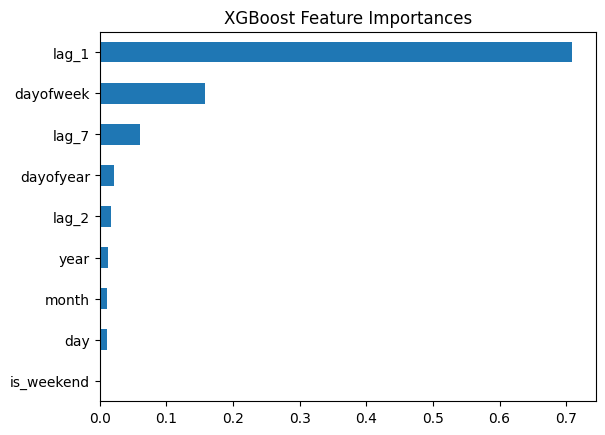

In [91]:
feat_importances_xgb = pd.Series(
    best_xgb_model.feature_importances_,
    index=X_train.columns
).sort_values()

feat_importances_xgb.plot(kind="barh")
plt.title("XGBoost Feature Importances")
plt.show()

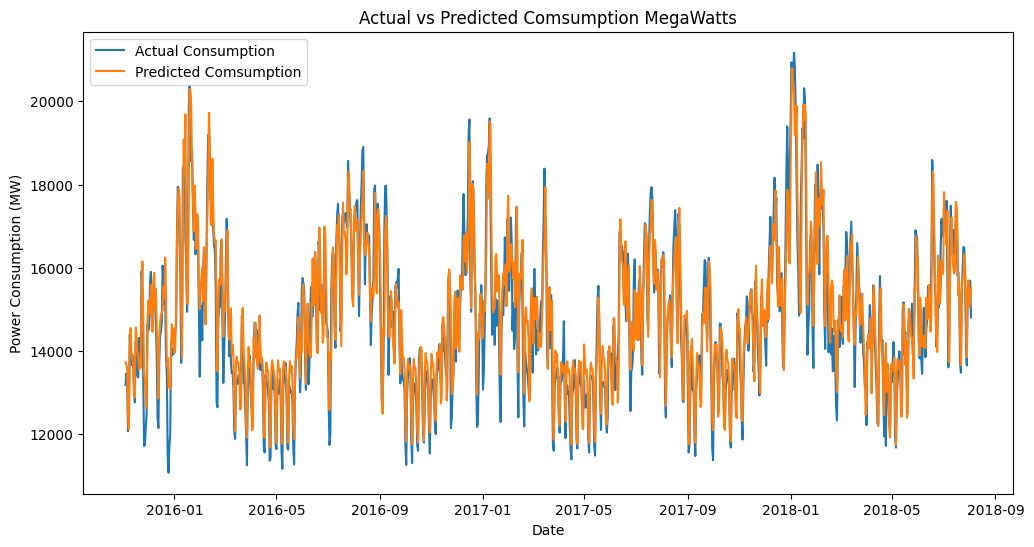

In [115]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(ML_test[['year','month','day']]), y_test, label='Actual Consumption')
plt.plot(pd.to_datetime(ML_test[['year','month','day']]), y_test_pred, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

Deployment

In [116]:
full_ml = pd.concat([train_proph, test_proph], ignore_index=True)
full_ml = full_ml.sort_values('ds').reset_index(drop=True)

last_test_date = test_proph['ds'].max()
print(f"Last date in test set : {last_test_date.date()}")
print(f"Forecasting up to     : {(last_test_date + pd.Timedelta(days=365)).date()}")

Last date in test set : 2018-08-03
Forecasting up to     : 2019-08-03


In [117]:
history = list(zip(full_ml['ds'], full_ml['y'])) 

future_dates  = pd.date_range(
    start=last_test_date + pd.Timedelta(days=1),
    periods=365,
    freq='D'
)

future_preds = []

for future_date in future_dates:

    recent = {d: v for d, v in history[-30:]}

    lag1_date = future_date - pd.Timedelta(days=1)
    lag2_date = future_date - pd.Timedelta(days=2)
    lag7_date = future_date - pd.Timedelta(days=7)

    lag_1 = recent.get(lag1_date, np.nan)
    lag_2 = recent.get(lag2_date, np.nan)
    lag_7 = recent.get(lag7_date, np.nan)

    row = pd.DataFrame([{
        'year'       : future_date.year,
        'month'      : future_date.month,
        'day'        : future_date.day,
        'dayofweek'  : future_date.dayofweek,
        'dayofyear'  : future_date.day_of_year,
        'is_weekend' : int(future_date.dayofweek in [5, 6]),
        'lag_1'      : lag_1,
        'lag_2'      : lag_2,
        'lag_7'      : lag_7,
    }])


    row = row[X_train.columns]

    pred = best_xgb_model.predict(row)[0]
    future_preds.append(pred)
    history.append((future_date, pred))

future_df = pd.DataFrame({'ds': future_dates, 'forecast': future_preds})
print(future_df.head())
print(f"\nForecast shape: {future_df.shape}")

          ds      forecast
0 2018-08-04  13773.811523
1 2018-08-05  13403.396484
2 2018-08-06  15446.514648
3 2018-08-07  15867.724609
4 2018-08-08  15778.665039

Forecast shape: (365, 2)


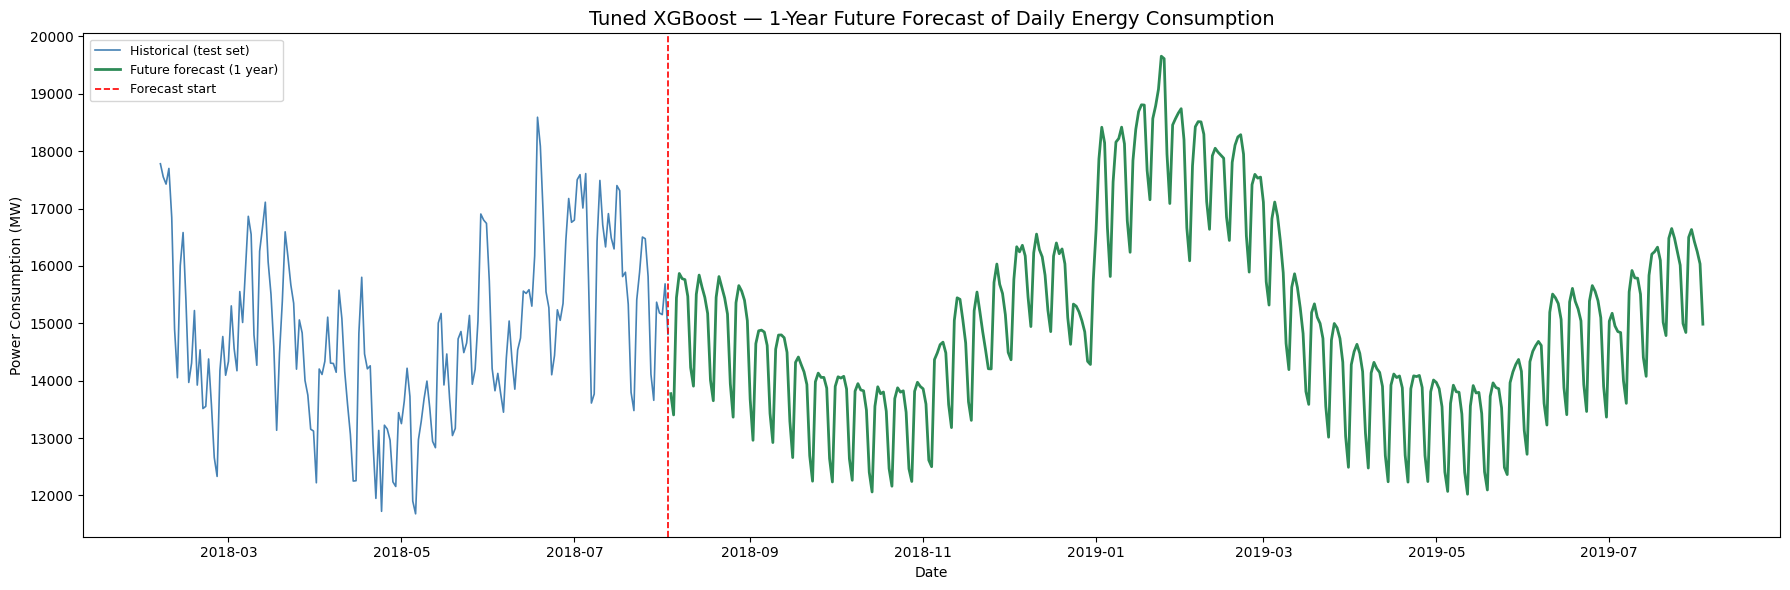

In [118]:
fig, ax = plt.subplots(figsize=(18, 6))

context = test_proph.tail(180)
ax.plot(context['ds'], context['y'],
        color='steelblue', linewidth=1.2, label='Historical (test set)')

ax.plot(future_df['ds'], future_df['forecast'],
        color='seagreen', linewidth=2, label='Future forecast (1 year)')


ax.axvline(last_test_date, color='red', linestyle='--', linewidth=1.2,
           label='Forecast start')

ax.set_title('Tuned XGBoost — 1-Year Future Forecast of Daily Energy Consumption',
             fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Power Consumption (MW)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [119]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_3)

In [ ]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False, random_state = 42
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))